In [1]:
!pip install pandas nltk matplotlib

In [2]:
import pandas as pd
import nltk
import matplotlib.pyplot as plt

In [3]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer

In [4]:
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [5]:
file = "facebook_sentiment_dataset.csv"

df = pd.read_csv(file)

print(df.head())

   Post_ID                                               Post
0        1         I really love this product, it is amazing!
1        2              Great service and very helpful staff.
2        3            This is an excellent update. Thank you!
3        4       I am very happy with the support I received.
4        5  Amazing experience, I would recommend this to ...


In [6]:
print(df.shape)
print(df.columns.tolist())

(20, 2)
['Post_ID', 'Post']


In [7]:
print(df.isnull().sum())

Post_ID    0
Post       0
dtype: int64


In [8]:
df = df.dropna(subset=['Post'])

print("Number of posts:", len(df))

Number of posts: 20


In [9]:
sid = SentimentIntensityAnalyzer()

In [10]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 20
Columns: 2


In [11]:
df['Sentiment_Score'] = df['Post'].apply(
    lambda x: sid.polarity_scores(str(x))['compound']
)

print(df[['Post', 'Sentiment_Score']])

                                                 Post  Sentiment_Score
0          I really love this product, it is amazing!           0.8620
1               Great service and very helpful staff.           0.8016
2             This is an excellent update. Thank you!           0.7574
3        I am very happy with the support I received.           0.7713
4   Amazing experience, I would recommend this to ...           0.7430
5         The event was wonderful and well organized.           0.7003
6           Very useful information. I learned a lot.           0.4927
7                         Fantastic work by the team!           0.5983
8                    I am satisfied with the service.           0.4215
9              This product is okay, nothing special.          -0.0920
10                        The experience was average.           0.0000
11                    It is fine but could be better.           0.6428
12                  I don't like this product at all.          -0.2755
13    

In [12]:
def classify_sentiment(score):
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

df['Sentiment'] = df['Sentiment_Score'].apply(classify_sentiment)

print(df[['Post', 'Sentiment_Score', 'Sentiment']])

                                                 Post  Sentiment_Score  \
0          I really love this product, it is amazing!           0.8620   
1               Great service and very helpful staff.           0.8016   
2             This is an excellent update. Thank you!           0.7574   
3        I am very happy with the support I received.           0.7713   
4   Amazing experience, I would recommend this to ...           0.7430   
5         The event was wonderful and well organized.           0.7003   
6           Very useful information. I learned a lot.           0.4927   
7                         Fantastic work by the team!           0.5983   
8                    I am satisfied with the service.           0.4215   
9              This product is okay, nothing special.          -0.0920   
10                        The experience was average.           0.0000   
11                    It is fine but could be better.           0.6428   
12                  I don't like this 

In [13]:
sentiment_counts = df['Sentiment'].value_counts()

print(sentiment_counts)

Sentiment
Positive    12
Negative     6
Neutral      2
Name: count, dtype: int64


In [14]:
positive_posts = df[df['Sentiment'] == 'Positive']

print("Positive posts:")
print(positive_posts[['Post_ID', 'Post', 'Sentiment']])

Positive posts:
    Post_ID                                               Post Sentiment
0         1         I really love this product, it is amazing!  Positive
1         2              Great service and very helpful staff.  Positive
2         3            This is an excellent update. Thank you!  Positive
3         4       I am very happy with the support I received.  Positive
4         5  Amazing experience, I would recommend this to ...  Positive
5         6        The event was wonderful and well organized.  Positive
6         7          Very useful information. I learned a lot.  Positive
7         8                        Fantastic work by the team!  Positive
8         9                   I am satisfied with the service.  Positive
11       12                    It is fine but could be better.  Positive
18       19                        Excellent work, keep it up!  Positive
19       20             Really good service and fast response.  Positive


In [15]:
positive_posts[['Post_ID', 'Post', 'Sentiment']]

,Post_ID,Post,Sentiment
0,1,"I really love this product, it is amazing!",Positive
1,2,Great service and very helpful staff.,Positive
2,3,This is an excellent update. Thank you!,Positive
3,4,I am very happy with the support I received.,Positive
4,5,"Amazing experience, I would recommend this to ...",Positive
5,6,The event was wonderful and well organized.,Positive
6,7,Very useful information. I learned a lot.,Positive
7,8,Fantastic work by the team!,Positive
8,9,I am satisfied with the service.,Positive
11,12,It is fine but could be better.,Positive


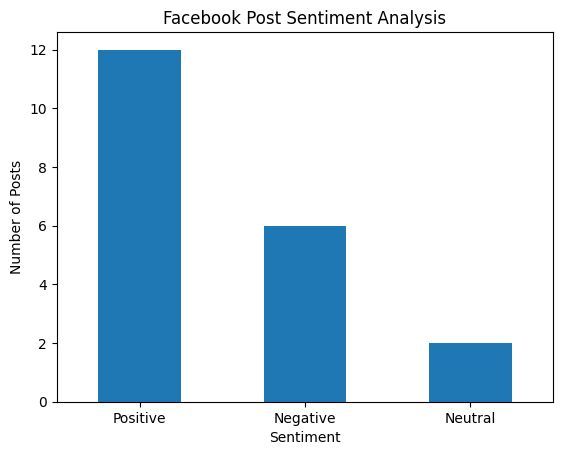

In [16]:
sentiment_counts.plot(kind='bar')

plt.title('Facebook Post Sentiment Analysis')
plt.xlabel('Sentiment')
plt.ylabel('Number of Posts')
plt.xticks(rotation=0)
plt.show()

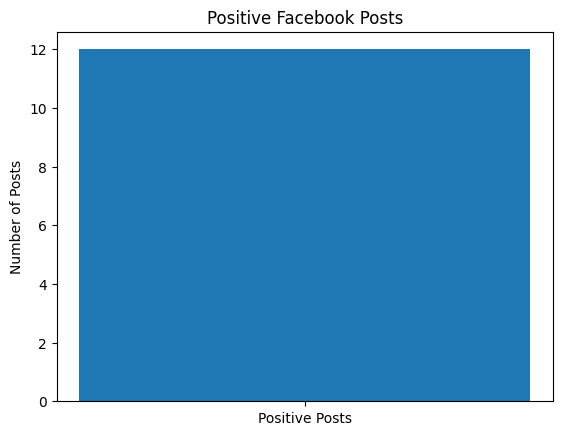

In [17]:
positive_count = len(positive_posts)

plt.bar(['Positive Posts'], [positive_count])

plt.title('Positive Facebook Posts')
plt.ylabel('Number of Posts')
plt.show()

In [18]:
positive_posts.to_csv(
    'positive_facebook_posts.csv',
    index=False
)

print("Positive posts saved successfully!")

Positive posts saved successfully!


In [19]:
print("Total posts:", len(df))
print("Positive posts:", len(df[df['Sentiment'] == 'Positive']))
print("Negative posts:", len(df[df['Sentiment'] == 'Negative']))
print("Neutral posts:", len(df[df['Sentiment'] == 'Neutral']))

Total posts: 20
Positive posts: 12
Negative posts: 6
Neutral posts: 2
